In [2]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425345 sha256=9e0aae16c1dd42a7273305bf7d43b30cc77f6c779168810b945c04de88242b1f
  Stored in directory: /root/.cache/pip/wheels/41/4e/10/c2cf2467f71c678cfc8a6b9ac9241e5e44a01940da8fbb17fc
Successfully built pyspark


In [3]:
!pip install findspark

In [4]:
!pip install spark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for spark: filename=spark-0.2.1-py3-none-any.whl size=58748 sha256=43d488cb21b5905bf57ce14017b6033b9de7cc498faa161a708c5355d1e8c7fb
  Stored in directory: /root/.cache/pip/wheels/63/88/77/b4131110ea4094540f7b47c6d62a649807d7e94800da5eab0b
Successfully built spark


In [5]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

In [6]:
from google.colab import files
files.upload()

Saving data.csv to data.csv


{'data.csv': b'"id","diagnosis","radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean","radius_se","texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave points_se","symmetry_se","fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst",\r\n842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189\r\n842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902\r\n84300903,M,1

In [8]:
OD = spark.read.csv("data.csv",header=True) #Creating a spark dataframe
OD.createOrReplaceTempView("OD")
print(spark.catalog.listTables())
OD.show(5)


[Table(name='OD', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]
+--------+---------+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+---------+----------+------------+-------+-------------+--------------+------------+-----------------+-----------+--------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+----+
|      id|diagnosis|radius_mean|texture_mean|perimeter_mean|area_mean|smoothness_mean|compactness_mean|concavity_mean|concave points_mean|symmetry_mean|fractal_dimension_mean|radius_se|texture_se|perimeter_se|area_se|smoothness_se|compactness_se|concavity_se|concave points_se|symmetry_se|fractal_dimension_se|radius_worst|texture_worst|perimeter_worst|area_worst|smoothness_worst|compactness_worst|concavity_wors

In [9]:
OD.printSchema()

root
 |-- id: string (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- radius_mean: string (nullable = true)
 |-- texture_mean: string (nullable = true)
 |-- perimeter_mean: string (nullable = true)
 |-- area_mean: string (nullable = true)
 |-- smoothness_mean: string (nullable = true)
 |-- compactness_mean: string (nullable = true)
 |-- concavity_mean: string (nullable = true)
 |-- concave points_mean: string (nullable = true)
 |-- symmetry_mean: string (nullable = true)
 |-- fractal_dimension_mean: string (nullable = true)
 |-- radius_se: string (nullable = true)
 |-- texture_se: string (nullable = true)
 |-- perimeter_se: string (nullable = true)
 |-- area_se: string (nullable = true)
 |-- smoothness_se: string (nullable = true)
 |-- compactness_se: string (nullable = true)
 |-- concavity_se: string (nullable = true)
 |-- concave points_se: string (nullable = true)
 |-- symmetry_se: string (nullable = true)
 |-- fractal_dimension_se: string (nullable = true)
 |-- radiu

In [10]:
print("Malignant count ",OD.filter(OD['diagnosis']=='M').select('diagnosis').count()) #Finding exact number's of each classes
print("Benign count ",OD.filter(OD['diagnosis']=='B').select('diagnosis').count()) #Unbalaced dataset

Malignant count  212
Benign count  357


In [11]:
from pyspark.ml.feature import StringIndexer #Converting diagnosis column into float numbers #0 for benign 1 for malignant
indexer = StringIndexer(inputCol="diagnosis", outputCol="label").fit(OD)
OD = indexer.transform(OD)

In [12]:
OD=OD.drop('_c32','diagnosis')#Getting quick statiscal values and droping unnessary columns
OD.describe().show()

+-------+--------------------+------------------+-----------------+-----------------+-----------------+--------------------+-------------------+-------------------+--------------------+--------------------+----------------------+------------------+------------------+------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+------------------+------------------+-----------------+--------------------+-------------------+-------------------+--------------------+-------------------+-----------------------+-------------------+
|summary|                  id|       radius_mean|     texture_mean|   perimeter_mean|        area_mean|     smoothness_mean|   compactness_mean|     concavity_mean| concave points_mean|       symmetry_mean|fractal_dimension_mean|         radius_se|        texture_se|      perimeter_se|          area_se|       smoothness_se|      compactness_se|  

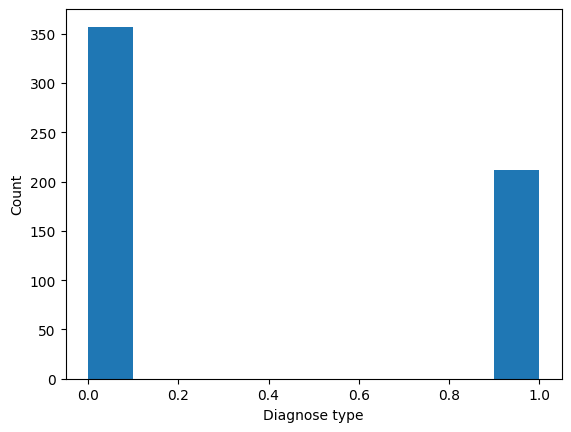

In [13]:
import matplotlib.pyplot as plt #Visualizing dataset's target classes
plt.hist([OD.select("label").collect()[i][0] for i in range(569)])
plt.xlabel("Diagnose type")
plt.ylabel("Count")
plt.show()

In [14]:
from pyspark.sql.types import *  #This methods cast all features into float type and returns new dataset
def cast(columns,df):
    for i in columns:
        df = df.withColumn(i, df[i].cast(FloatType()))
    return df

In [15]:
OD=cast(OD.columns,OD) #Casting all features into float type except label(diagnosis column)
OD=OD.withColumn("label",OD["label"].cast(IntegerType())) #converting label into integer type

In [16]:
OD.printSchema() #Checking dataset's features type after cast method, They are all float and integer

root
 |-- id: float (nullable = true)
 |-- radius_mean: float (nullable = true)
 |-- texture_mean: float (nullable = true)
 |-- perimeter_mean: float (nullable = true)
 |-- area_mean: float (nullable = true)
 |-- smoothness_mean: float (nullable = true)
 |-- compactness_mean: float (nullable = true)
 |-- concavity_mean: float (nullable = true)
 |-- concave points_mean: float (nullable = true)
 |-- symmetry_mean: float (nullable = true)
 |-- fractal_dimension_mean: float (nullable = true)
 |-- radius_se: float (nullable = true)
 |-- texture_se: float (nullable = true)
 |-- perimeter_se: float (nullable = true)
 |-- area_se: float (nullable = true)
 |-- smoothness_se: float (nullable = true)
 |-- compactness_se: float (nullable = true)
 |-- concavity_se: float (nullable = true)
 |-- concave points_se: float (nullable = true)
 |-- symmetry_se: float (nullable = true)
 |-- fractal_dimension_se: float (nullable = true)
 |-- radius_worst: float (nullable = true)
 |-- texture_worst: float (nu

In [17]:
from pyspark.ml.clustering import KMeans  #ND dataset contains both scaled and not scaled feature vector, I used these vector in modeling stage
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml import Pipeline
assembler = VectorAssembler().setInputCols\
            (OD.drop("label","id").columns).setOutputCol("features")
transformed = assembler.transform(OD)
scaler = MinMaxScaler(inputCol="features",\
         outputCol="sf")
scalerModel =  scaler.fit(transformed.select("features"))
ND = scalerModel.transform(transformed)

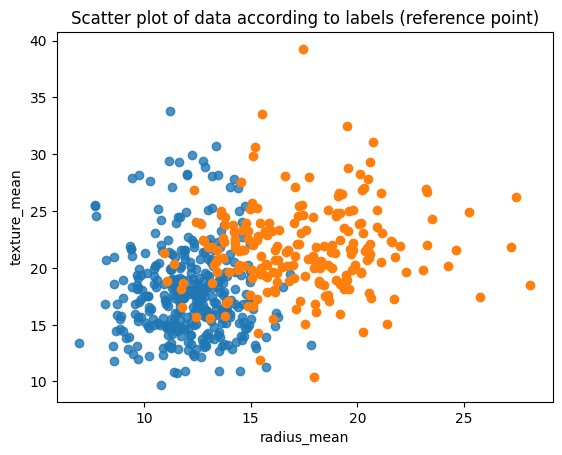

In [18]:
#reference point
tempM=OD[OD.label==1.0].toPandas()
tempB=OD[OD.label==0.0].toPandas()
plt.scatter(tempB['radius_mean'],tempB['texture_mean'],alpha=0.8)
plt.scatter(tempM['radius_mean'],tempM['texture_mean'],alpha=1)
plt.title('Scatter plot of data according to labels (reference point)')
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
plt.show()

In [19]:
from pyspark.ml.clustering import KMeans

kmeansOD = KMeans(k=2, seed=42)  # 2 clusters for 2 target classes
modelOD = kmeansOD.fit(ND.select('features'))
transformedOD = modelOD.transform(ND)

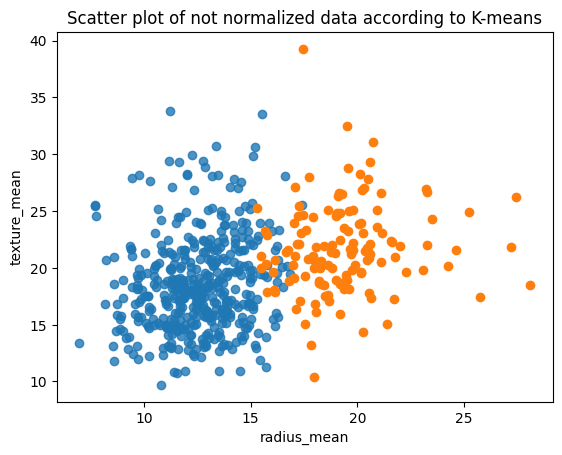

In [20]:
import matplotlib.pyplot as plt #Not normalized dataset's cluster visualization
tempM=transformedOD[transformedOD.prediction==1].toPandas()
tempB=transformedOD[transformedOD.prediction==0].toPandas()
plt.scatter(tempB['radius_mean'],tempB['texture_mean'],alpha=0.8)
plt.scatter(tempM['radius_mean'],tempM['texture_mean'],alpha=1)
plt.title('Scatter plot of not normalized data according to K-means')
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
plt.show()

In [21]:
#Cluster report for not normalized data (all features included)
from sklearn.metrics import classification_report
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns; sns.set()
tempM=transformedOD[transformedOD.prediction==1].toPandas()
tempB=transformedOD[transformedOD.prediction==0].toPandas()
result = pd.concat([tempM,tempB])
true_labels=(OD.orderBy("id").select("label")).toPandas()
predicted_labels=result.sort_values("id")["prediction"]
print("Cluster report for not normalized data (all features included)\n",classification_report(true_labels, predicted_labels),"\n")
cm=confusion_matrix(true_labels, predicted_labels)
print("Confusion matrix\n",cm)
#As you can see algorithm is a little bit weak on predicting malignant(1)classes due to unbalanced dataset

Cluster report for not normalized data (all features included)
               precision    recall  f1-score   support

           0       0.81      1.00      0.90       357
           1       0.99      0.61      0.76       212

    accuracy                           0.85       569
   macro avg       0.90      0.81      0.83       569
weighted avg       0.88      0.85      0.84       569
 

Confusion matrix
 [[356   1]
 [ 82 130]]


In [22]:
nd=ND.drop("features")
nd=nd.withColumnRenamed("sf", "features")# renaming scaled feature column because sometimes spark gives error
kmeans = KMeans(k=2, seed=42)  # 2 clusters here
model = kmeans.fit(nd.select('features'))
transformed = model.transform(nd)

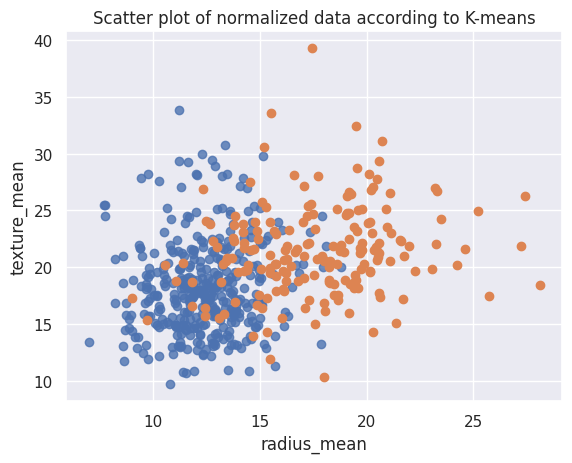

In [23]:
tempM=transformed[transformed.prediction==1].toPandas()
tempB=transformed[transformed.prediction==0].toPandas()
plt.scatter(tempB['radius_mean'],tempB['texture_mean'],alpha=0.8)
plt.scatter(tempM['radius_mean'],tempM['texture_mean'],alpha=1)
plt.title('Scatter plot of normalized data according to K-means')
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
plt.show()

In [24]:
#Cluster report for normalized data (all features included)
from sklearn.metrics import classification_report
import pandas as pd
tempM=transformed[transformed.prediction==1].toPandas()#we say all malignant
tempB=transformed[transformed.prediction==0].toPandas()#we say all beningn
result = pd.concat([tempM,tempB])
true_labels=(OD.orderBy("id").select("label")).toPandas()
predicted_labels=result.sort_values("id")["prediction"]
print("Cluster report for  normalized data (all features included)\n",classification_report(true_labels, predicted_labels),"\n")
cmN=confusion_matrix(true_labels, predicted_labels)
print("Confusion matrix\n",cmN)
#Better results on both target classes according to not normalized dataset

Cluster report for  normalized data (all features included)
               precision    recall  f1-score   support

           0       0.92      0.97      0.94       357
           1       0.95      0.85      0.90       212

    accuracy                           0.93       569
   macro avg       0.93      0.91      0.92       569
weighted avg       0.93      0.93      0.93       569
 

Confusion matrix
 [[348   9]
 [ 32 180]]


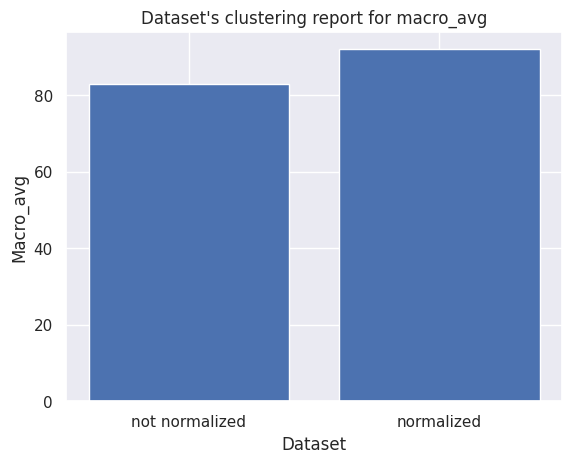

In [25]:
plt.bar(["not normalized","normalized"],[83,92])
plt.title("Dataset's clustering report for macro_avg")
plt.xlabel("Dataset")
plt.ylabel("Macro_avg")
plt.show()

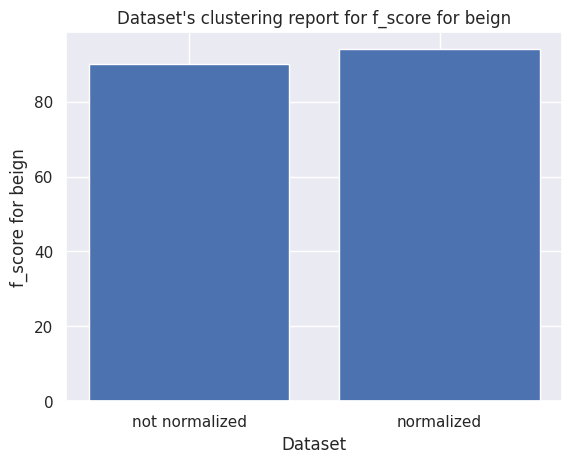

In [26]:
plt.bar(["not normalized","normalized"],[90,94])
plt.title("Dataset's clustering report for f_score for beign")
plt.xlabel("Dataset")
plt.ylabel("f_score for beign")
plt.show()

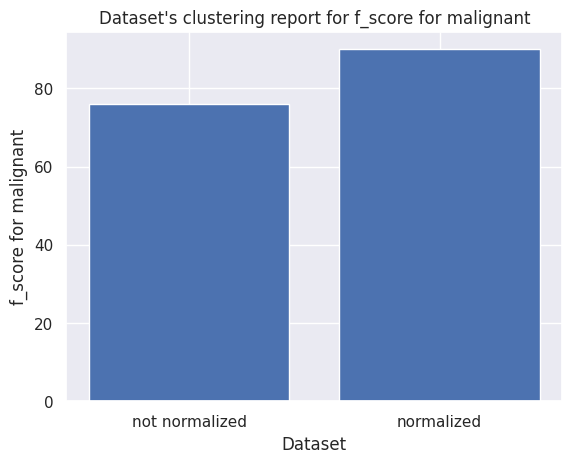

In [27]:
plt.bar(["not normalized","normalized"],[76,90])
plt.title("Dataset's clustering report for f_score for malignant")
plt.xlabel("Dataset")
plt.ylabel("f_score for malignant")
plt.show()

Confusion matrix for not normalized dataset


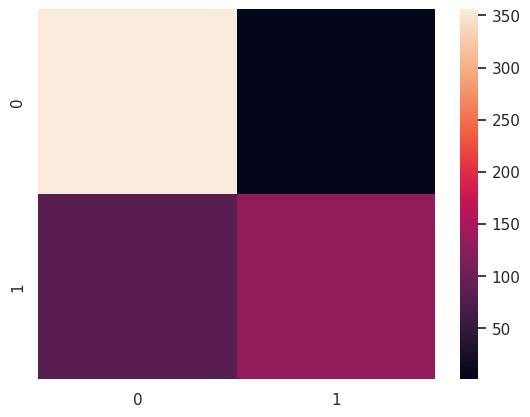

In [28]:
print("Confusion matrix for not normalized dataset")
ax = sns.heatmap(cm)


Confusion matrix for normalized dataset


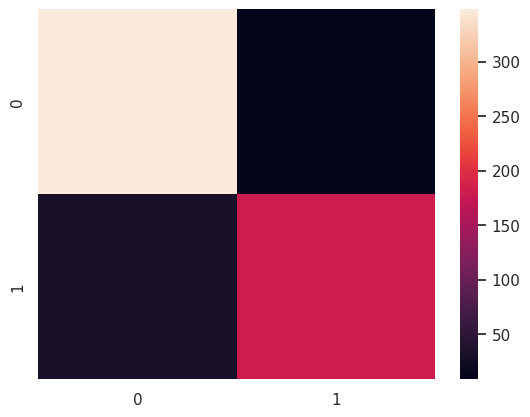

In [29]:
print("Confusion matrix for normalized dataset")
ax = sns.heatmap(cmN)

In [30]:
(trainingData, testData) = transformedOD.select("label","features","id").randomSplit([0.7, 0.3],seed=100) #Firstly split the dataset into train and test

In [31]:
#Normalizing training set
scaler1 = MinMaxScaler(inputCol="features",\
         outputCol="sf")
scalerModel1 =  scaler1.fit(trainingData.select("features"))
trainingData = scalerModel1.transform(trainingData)
trainingData=trainingData.drop("features")
trainingData=trainingData.withColumnRenamed("sf","features")

In [32]:
#Normalizing test dataset
scaler = MinMaxScaler(inputCol="features",\
         outputCol="sf")
scalerModel =  scaler.fit(testData.select("features"))
testData = scalerModel.transform(testData)
testData=testData.drop("features")
testData=testData.withColumnRenamed("sf","features")

In [33]:
from pyspark.ml.classification import RandomForestClassifier #Random Forest model (all features inclued).It is also a reference point for feature selection
rf = RandomForestClassifier(featuresCol = 'features', labelCol = 'label',seed=-3087325413071123553)
rfModel = rf.fit(trainingData)
predictions = rfModel.transform(testData)

In [34]:
tempM=predictions[predictions.prediction==1].toPandas()#we say all malignant
tempB=predictions[predictions.prediction==0].toPandas()#we say all beningn
result = pd.concat([tempM,tempB])
true_labels=(testData.orderBy("id").select("label")).toPandas()
predicted_labels=result.sort_values("id")["prediction"]
print("Random Forest Classification report for  normalized data (all features included)\n",classification_report(true_labels, predicted_labels),"\n")
print("Confusion matrix for model\n",confusion_matrix(true_labels,predicted_labels),"\n\n")
rfA=confusion_matrix(true_labels,predicted_labels)

Random Forest Classification report for  normalized data (all features included)
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171
 

Confusion matrix for model
 [[107   0]
 [  5  59]] 




In [35]:
from pyspark.ml.classification import GBTClassifier #Gradient Boost classifier for all features
gbt = GBTClassifier(maxIter=10,seed=-1921504167437407479)
gbtModel = gbt.fit(trainingData)
predictions2 = gbtModel.transform(testData)

In [36]:
tempM=predictions2[predictions2.prediction==1].toPandas()#we say all malignant
tempB=predictions2[predictions2.prediction==0].toPandas()#we say all beningn
result = pd.concat([tempM,tempB])
true_labels=(testData.orderBy("id").select("label")).toPandas()
predicted_labels=result.sort_values("id")["prediction"]
print("Gradient Boost Classification report for  normalized data (all features included)\n",classification_report(true_labels, predicted_labels),"\n")
print("Confusion matrix for model\n",confusion_matrix(true_labels,predicted_labels),"\n\n")
gbtA=confusion_matrix(true_labels,predicted_labels)

Gradient Boost Classification report for  normalized data (all features included)
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       107
           1       0.95      0.88      0.91        64

    accuracy                           0.94       171
   macro avg       0.94      0.92      0.93       171
weighted avg       0.94      0.94      0.94       171
 

Confusion matrix for model
 [[104   3]
 [  8  56]] 




In [37]:
imp=sorted(rfModel.featureImportances,reverse=True)[:20] #Getting the most important 20 features from information gain selection
importantColumns=[]
for i in rfModel.featureImportances.indices:
    if rfModel.featureImportances.toArray()[i] in imp:
        importantColumns.append(i)

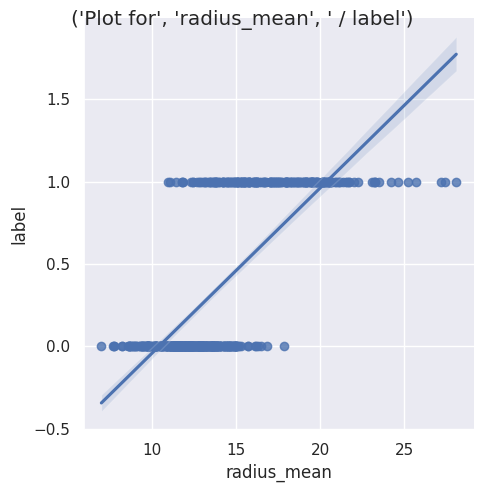

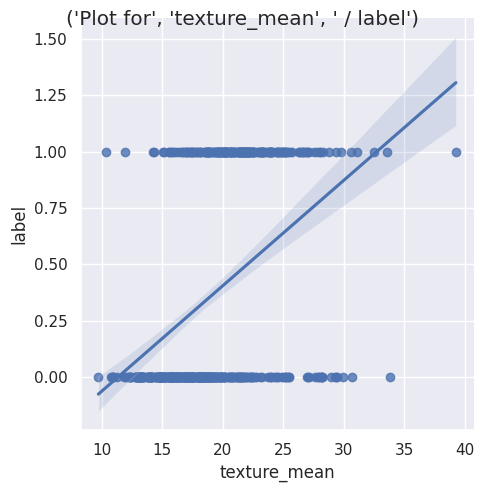

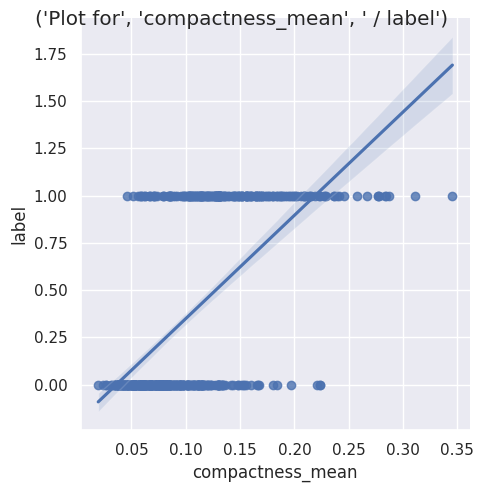

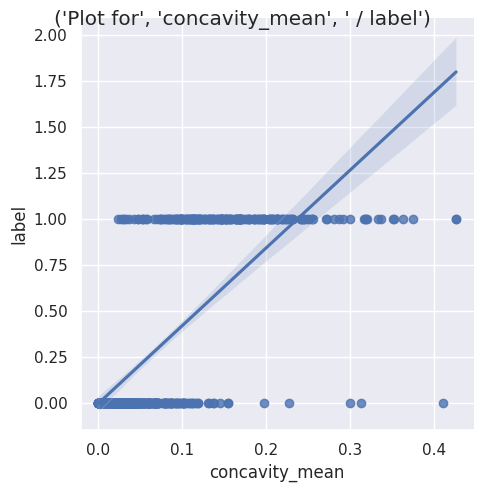

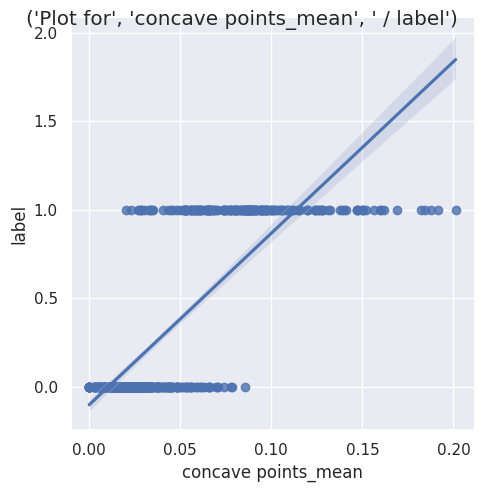

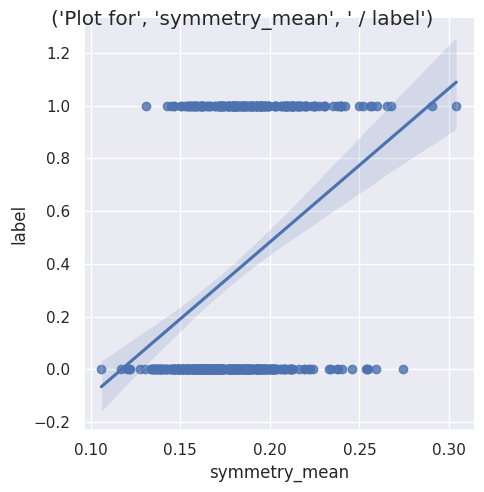

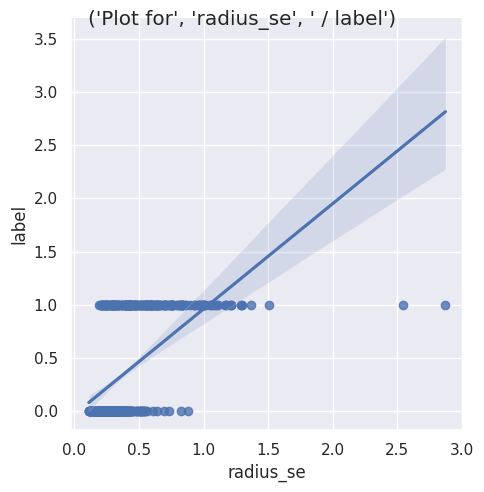

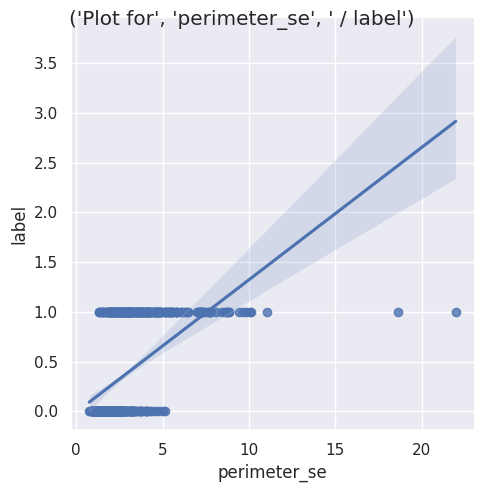

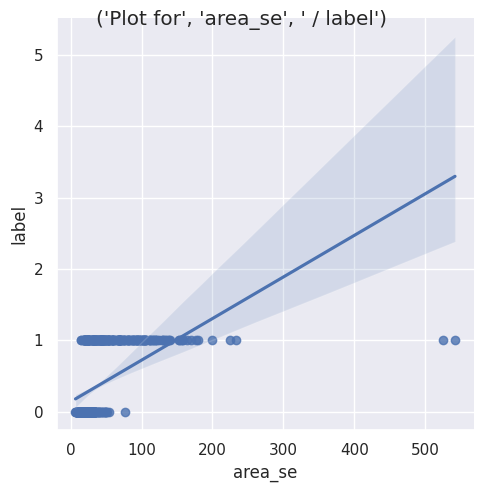

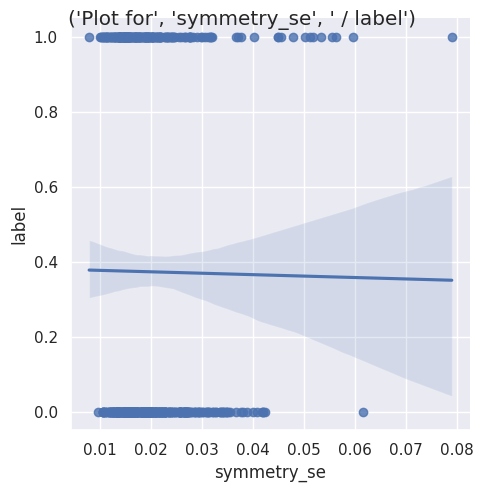

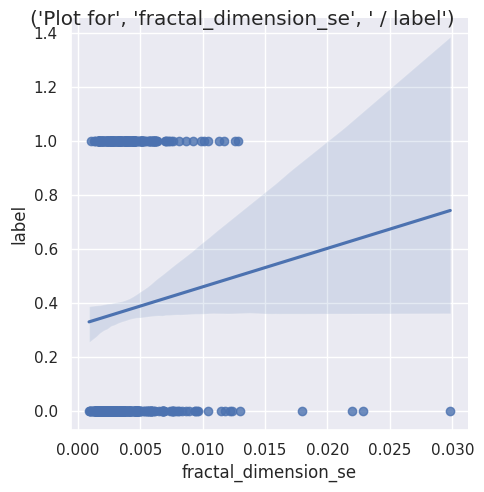

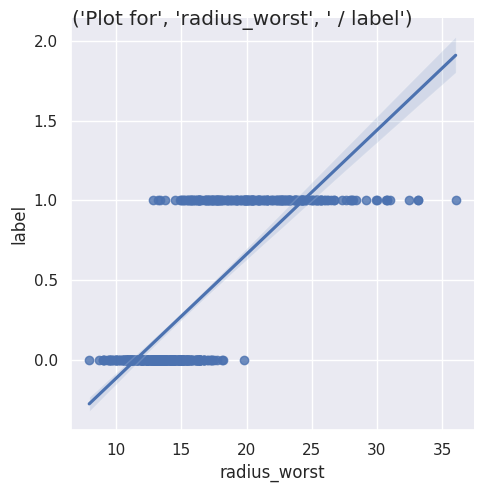

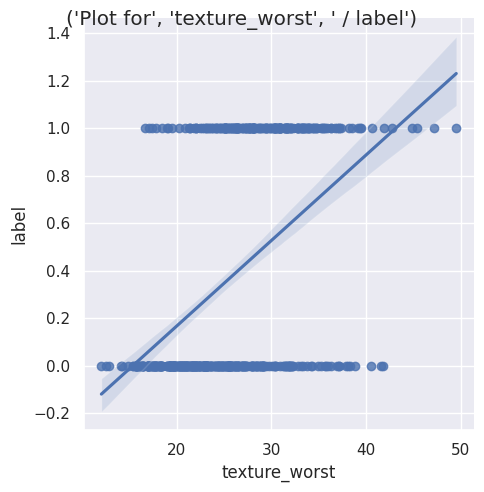

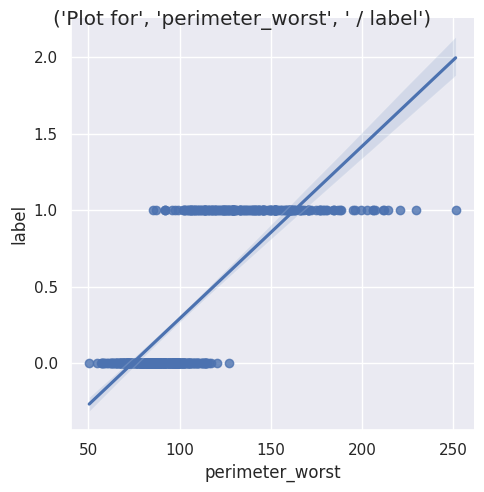

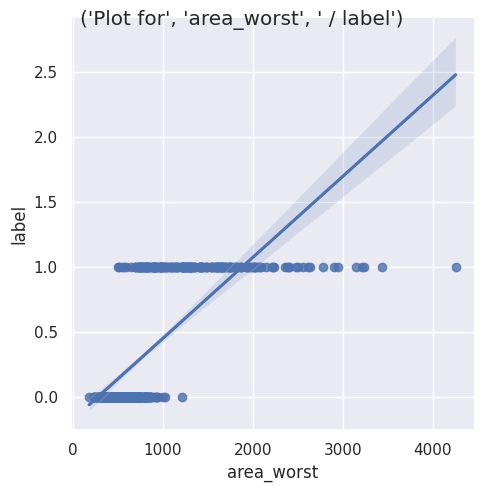

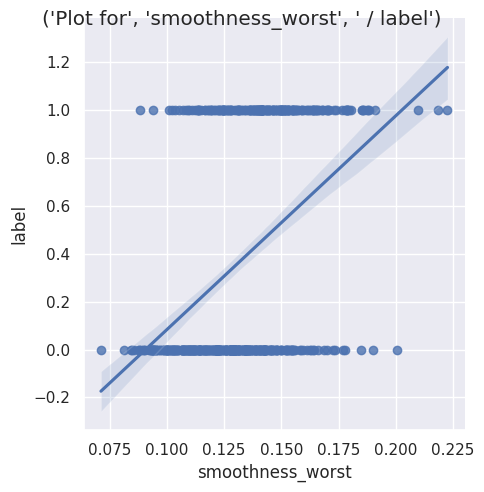

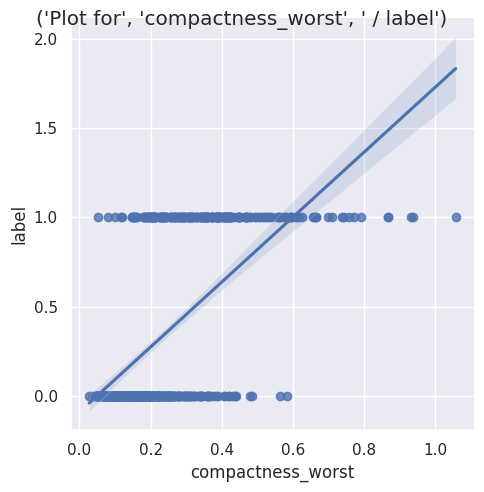

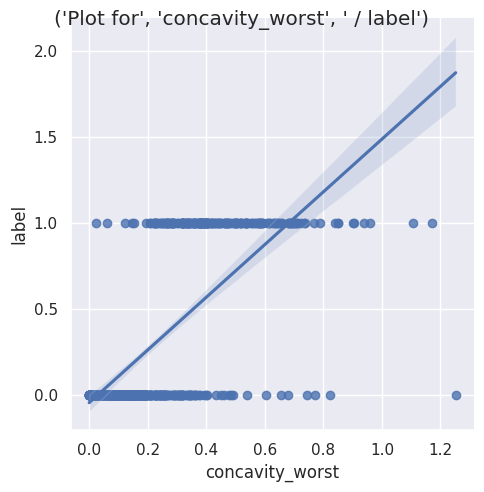

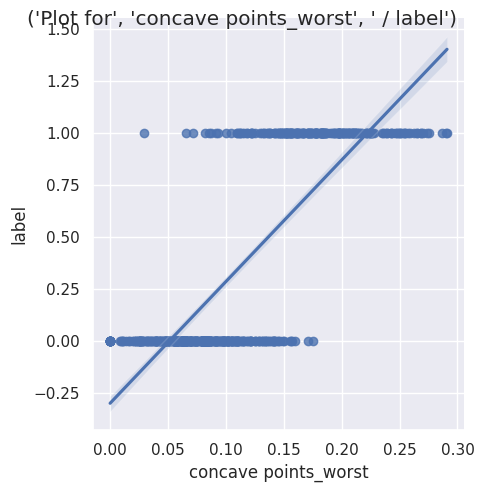

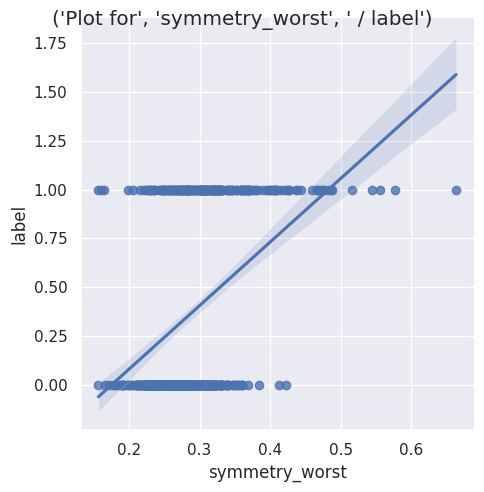

In [38]:
#Analysing important columns correlations with lmplot
for i in importantColumns:
    sns.lmplot(x=OD.drop("id","label").columns[i], y="label",data=OD.toPandas()).fig.suptitle(("Plot for",OD.drop("id","label").columns[i]," / label"))

In [39]:
#Creating a new dataset with only most important 20 features
assemblerr = VectorAssembler().setInputCols\
            ([OD.drop("label","id").columns[i] for i in importantColumns]).setOutputCol("features")
RND = assemblerr.transform(OD)

In [40]:
(trainingDataReduced, testDataReduced) = RND.select("label","features","id").randomSplit([0.7, 0.3],seed=100) #Splitting dataset into train and test


In [41]:
#Normalizing the training set
scaler1r = MinMaxScaler(inputCol="features",\
         outputCol="sf")
scalerModel1r =  scaler1r.fit(trainingDataReduced.select("features"))
trainingDataReduced = scalerModel1r.transform(trainingDataReduced)
trainingDataReduced=trainingDataReduced.drop("features")
trainingDataReduced=trainingDataReduced.withColumnRenamed("sf","features")

In [42]:
#Normalizing the test set
scalerr = MinMaxScaler(inputCol="features",\
         outputCol="sf")
scalerModelr =  scalerr.fit(testDataReduced.select("features"))
testDataReduced = scalerModelr.transform(testDataReduced)
testDataReduced=testDataReduced.drop("features")
testDataReduced=testDataReduced.withColumnRenamed("sf","features")

In [43]:
rfr = RandomForestClassifier(featuresCol = 'features', labelCol = 'label',seed=-3087325413071123553)#Creating Random-Forest model for selected features
rfModelr = rfr.fit(trainingDataReduced)
predictionsr = rfModelr.transform(testDataReduced)

In [44]:
tempM=predictionsr[predictionsr.prediction==1].toPandas()#we say all malignant
tempB=predictionsr[predictionsr.prediction==0].toPandas()#we say all beningn
result = pd.concat([tempM,tempB])
true_labels=(testDataReduced.orderBy("id").select("label")).toPandas()
predicted_labels=result.sort_values("id")["prediction"]
print("Random Forest Classification report for  normalized data (feature selection used)\n",classification_report(true_labels, predicted_labels),"\n")
print("Confusion matrix for model\n",confusion_matrix(true_labels,predicted_labels),"\n\n")
rfR=confusion_matrix(true_labels,predicted_labels)

Random Forest Classification report for  normalized data (feature selection used)
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171
 

Confusion matrix for model
 [[107   0]
 [  5  59]] 




In [45]:
gbt = GBTClassifier(maxIter=10,seed=-1921504167437407479) #Creating Gradient Boost algorithm with feature selection
gbtModel = gbt.fit(trainingDataReduced)
predictions2r = gbtModel.transform(testDataReduced)

In [46]:
tempM=predictions2r[predictions2r.prediction==1].toPandas()#we say all malignant
tempB=predictions2r[predictions2r.prediction==0].toPandas()#we say all beningn
result = pd.concat([tempM,tempB])
true_labels=(testDataReduced.orderBy("id").select("label")).toPandas()
predicted_labels=result.sort_values("id")["prediction"]
print("Gradient Boost Classification report for  normalized data (feature selection used)\n",classification_report(true_labels, predicted_labels),"\n")
print("Confusion matrix for model\n",confusion_matrix(true_labels,predicted_labels),"\n\n")
gbtR=confusion_matrix(true_labels, predicted_labels)

Gradient Boost Classification report for  normalized data (feature selection used)
               precision    recall  f1-score   support

           0       0.94      0.97      0.95       107
           1       0.95      0.89      0.92        64

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171
 

Confusion matrix for model
 [[104   3]
 [  7  57]] 




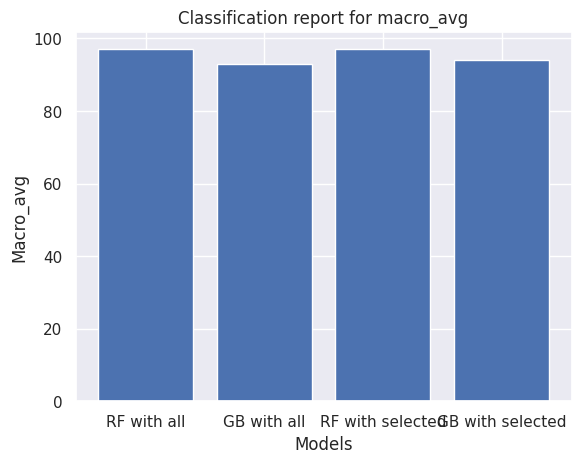

In [47]:
plt.bar(["RF with all","GB with all","RF with selected","GB with selected"],[97,93,97,94])
plt.title("Classification report for macro_avg")
plt.xlabel("Models")
plt.ylabel("Macro_avg")
plt.show()

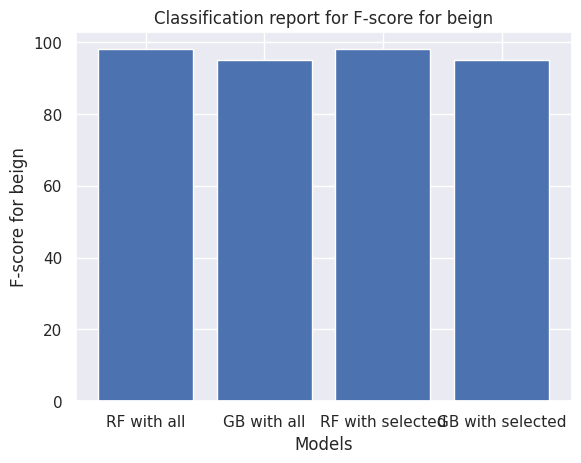

In [48]:
plt.bar(["RF with all","GB with all","RF with selected","GB with selected"],[98,95,98,95])
plt.title("Classification report for F-score for beign")
plt.xlabel("Models")
plt.ylabel("F-score for beign")
plt.show()

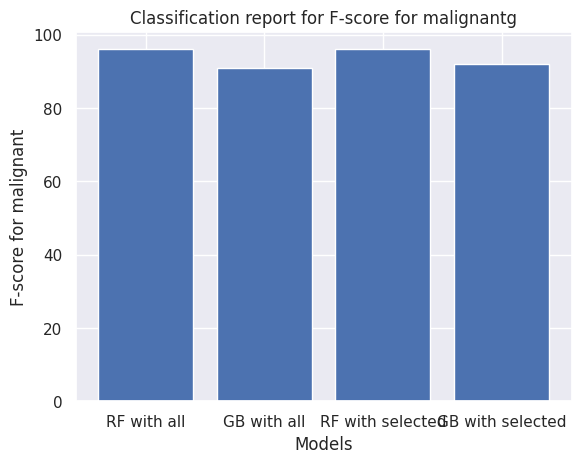

In [49]:
plt.bar(["RF with all","GB with all","RF with selected","GB with selected"],[96,91,96,92])
plt.title("Classification report for F-score for malignantg")
plt.xlabel("Models")
plt.ylabel("F-score for malignant")
plt.show()

Confusion matrix for Random-Forest with all features
 [[107   0]
 [  5  59]] 




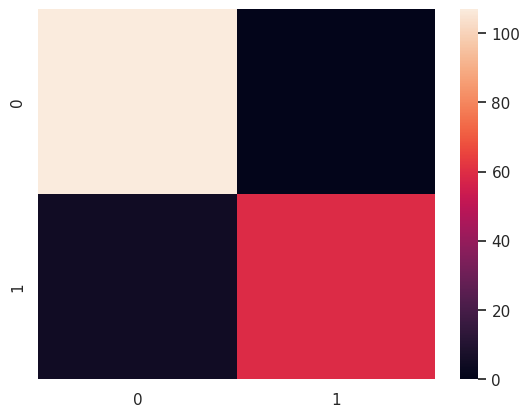

In [50]:
print("Confusion matrix for Random-Forest with all features\n",rfA,"\n\n")
ax = sns.heatmap(rfA)

Confusion matrix for Random-Forest with selected features
 [[107   0]
 [  5  59]] 




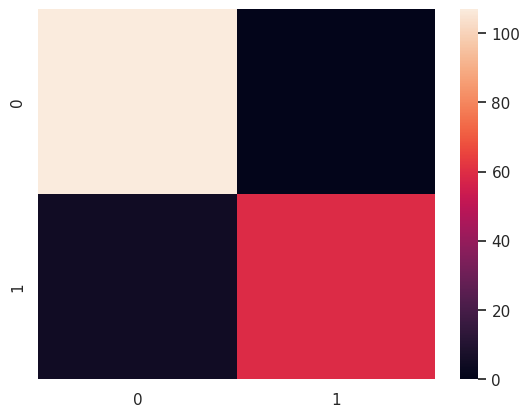

In [51]:
print("Confusion matrix for Random-Forest with selected features\n",rfR,"\n\n")
ax = sns.heatmap(rfR)


Confusion matrix for Gradient Boost with all features
 [[104   3]
 [  8  56]] 




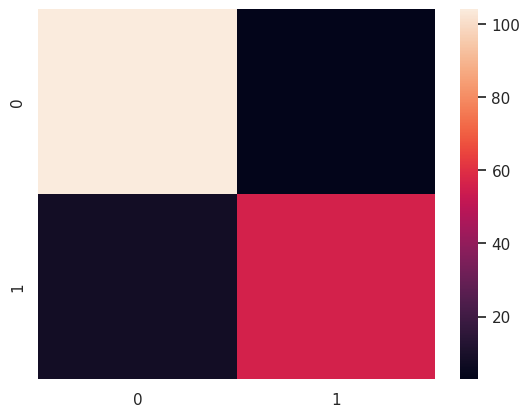

In [52]:
print("Confusion matrix for Gradient Boost with all features\n",gbtA,"\n\n")
ax = sns.heatmap(gbtA)

Confusion matrix for Gradient Boost with selected features
 [[104   3]
 [  7  57]] 




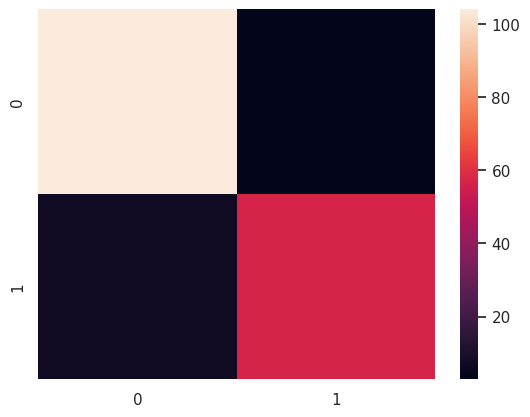

In [53]:
print("Confusion matrix for Gradient Boost with selected features\n",gbtR,"\n\n")
ax = sns.heatmap(gbtR)

In [54]:
#Roc curve area for Random forest all features
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
print("Roc curve area for Random forest all features",evaluator.evaluate(predictions))

Roc curve area for Random forest all features 0.9966413551401868


In [55]:
#Roc curve area for Random forest selected features
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
print("Roc curve area for Random forest selected features",evaluator.evaluate(predictionsr))

Roc curve area for Random forest selected features 0.9964953271028036


In [56]:
#Roc curve area for Gradient Boost all features
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
print("Roc curve area for Gradient Boost all features features",evaluator.evaluate(predictions2))

Roc curve area for Gradient Boost all features features 0.968238901869159


In [57]:
#Roc curve area for Gradient Boost selected features
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
print("Roc curve area for Gradient Boost selected features features",evaluator.evaluate(predictions2r))

Roc curve area for Gradient Boost selected features features 0.9779497663551401


In [75]:
from pyspark.ml.classification import LogisticRegression

In [76]:
model = LogisticRegression(labelCol='label')
model

LogisticRegression_a7d92f12b91d

In [78]:
trained_model = model.fit(trainingDataReduced)

In [62]:
train_predictions = trained_model.evaluate(trainingDataReduced).predictions
train_predictions.show(5)

+-----+-----------+--------------------+--------------------+--------------------+----------+
|label|         id|            features|       rawPrediction|         probability|prediction|
+-----+-----------+--------------------+--------------------+--------------------+----------+
|    0|   862722.0|(20,[1,2,5,6,7,8,...|[31.2129394608844...|[0.99999999999997...|       0.0|
|    0|   921362.0|[0.03360310548737...|[18.7460795318948...|[0.99999999277760...|       0.0|
|    0|   921092.0|[0.03540158651429...|[16.0516449528269...|[0.99999989312918...|       0.0|
|    0|8.5713704E7|[0.05750391000138...|[24.5740637518930...|[0.99999999997873...|       0.0|
|    0|8.7100147E8|[0.05859245005374...|[19.3751167464649...|[0.99999999614970...|       0.0|
+-----+-----------+--------------------+--------------------+--------------------+----------+
only showing top 5 rows



In [63]:
train_df_count_1 = trainingDataReduced.filter(trainingDataReduced['label'] == 1).count()
train_df_count_0 = trainingDataReduced.filter(trainingDataReduced['label'] == 0).count()
train_df_count_1, train_df_count_0

(148, 250)

In [64]:
cp = train_predictions.filter(
train_predictions['label'] == 1).filter(
train_predictions['prediction'] == 1).select(
['label','prediction','probability'])
print("Correct predictions: ", cp.count())
accuracy = (cp.count()) /  train_df_count_1
print(f"Accuracy: {accuracy}\n")
cp.show(5,False)

Correct predictions:  144
Accuracy: 0.972972972972973

+-----+----------+------------------------------------------+
|label|prediction|probability                               |
+-----+----------+------------------------------------------+
|1    |1.0       |[6.509161355408517E-9,0.9999999934908387] |
|1    |1.0       |[0.0024837599505286466,0.9975162400494714]|
|1    |1.0       |[1.149856591925068E-12,0.9999999999988501]|
|1    |1.0       |[8.614469182645797E-8,0.9999999138553082] |
|1    |1.0       |[2.720175364615796E-6,0.9999972798246354] |
+-----+----------+------------------------------------------+
only showing top 5 rows



In [65]:
fp = train_predictions.filter(
train_predictions['label'] == 0).filter(
train_predictions['prediction'] == 1).select(
['label','prediction','probability'])
print("False positive: ", fp.count())
fp.show(5,False)

False positive:  3
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |1.0       |[0.13531655960323136,0.8646834403967687]|
|0    |1.0       |[0.3625912717712606,0.6374087282287394] |
|0    |1.0       |[0.4627171184357803,0.5372828815642197] |
+-----+----------+----------------------------------------+



In [66]:
fn = train_predictions.filter(
train_predictions['label'] == 1).filter(
train_predictions['prediction'] == 0).select(
['label','prediction','probability'])
print("False negative: ", fn.count())
fn.show(5,False)

False negative:  4
+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|1    |0.0       |[0.9763513030329368,0.023648696967063176]|
|1    |0.0       |[0.5012063915016879,0.4987936084983121]  |
|1    |0.0       |[0.8568684973091306,0.14313150269086938] |
|1    |0.0       |[0.6607802337059951,0.33921976629400485] |
+-----+----------+-----------------------------------------+



In [68]:
test_predictions = trained_model.evaluate(testDataReduced).predictions
test_predictions.show(5, False)

+-----+--------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------+------------------------------------------+----------+
|label|id      |features                                                                                                                                                                                                                                                                                                                                                                                        |rawPrediction                           |probability                               |prediction|
+-----

In [70]:
test_df_count_1 = testDataReduced.filter(testDataReduced['label'] == 1).count()
test_df_count_0 = testDataReduced.filter(testDataReduced['label'] == 0).count()
test_df_count_1, test_df_count_0

(64, 107)

In [71]:
cp = test_predictions.filter(
test_predictions['label'] == 1).filter(
test_predictions['prediction'] == 1).select(
['label','prediction','probability'])
print("Correct predictions: ", cp.count())
accuracy = (cp.count()) /  test_df_count_1
print(f"Accuracy: {accuracy}\n")
cp.show(5,False)

Correct predictions:  59
Accuracy: 0.921875

+-----+----------+-------------------------------------------+
|label|prediction|probability                                |
+-----+----------+-------------------------------------------+
|1    |1.0       |[6.225423346978651E-4,0.9993774576653022]  |
|1    |1.0       |[2.413221070029829E-5,0.9999758677892997]  |
|1    |1.0       |[1.30227075627664E-9,0.9999999986977293]   |
|1    |1.0       |[1.3378508347923147E-6,0.9999986621491652] |
|1    |1.0       |[1.1962431134252273E-10,0.9999999998803757]|
+-----+----------+-------------------------------------------+
only showing top 5 rows



In [72]:
fp = test_predictions.filter(
test_predictions['label'] == 0).filter(
test_predictions['prediction'] == 1).select(
['label','prediction','probability'])
print("False positive: ", fp.count())
fp.show(5,False)

False positive:  1
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |1.0       |[0.19620660165552276,0.8037933983444773]|
+-----+----------+----------------------------------------+



In [73]:
fn = test_predictions.filter(
test_predictions['label'] == 1).filter(
test_predictions['prediction'] == 0).select(
['label','prediction','probability'])
print("False negative: ", fn.count())
fn.show(5,False)

False negative:  5
+-----+----------+------------------------------------------+
|label|prediction|probability                               |
+-----+----------+------------------------------------------+
|1    |0.0       |[0.9016927648537498,0.09830723514625017]  |
|1    |0.0       |[0.9884128831350899,0.011587116864910096] |
|1    |0.0       |[0.9987230762001987,0.0012769237998012661]|
|1    |0.0       |[0.9039991634127409,0.09600083658725911]  |
|1    |0.0       |[0.928135359401354,0.07186464059864595]   |
+-----+----------+------------------------------------------+



IllegalArgumentException: _c30 does not exist. Available: label, id, features, rawPrediction, probability, prediction

In [81]:
from pyspark.sql import SparkSession

In [82]:
spark = SparkSession.builder.appName('regression').getOrCreate()

In [87]:
#read the dataset
df = spark.read.csv('/content/data.csv', inferSchema=True, header=True)
#view five records
df.show(5)

+--------+---------+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+---------+----------+------------+-------+-------------+--------------+------------+-----------------+-----------+--------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+----+
|      id|diagnosis|radius_mean|texture_mean|perimeter_mean|area_mean|smoothness_mean|compactness_mean|concavity_mean|concave points_mean|symmetry_mean|fractal_dimension_mean|radius_se|texture_se|perimeter_se|area_se|smoothness_se|compactness_se|concavity_se|concave points_se|symmetry_se|fractal_dimension_se|radius_worst|texture_worst|perimeter_worst|area_worst|smoothness_worst|compactness_worst|concavity_worst|concave points_worst|symmetry_worst|fractal_dimension_worst|_c32|
+--------+---------+-----------+------

In [88]:
#print dataframe columns and count
print(df.columns)
print(df.count())

['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', '_c32']
569


In [89]:
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- radius_mean: double (nullable = true)
 |-- texture_mean: double (nullable = true)
 |-- perimeter_mean: double (nullable = true)
 |-- area_mean: double (nullable = true)
 |-- smoothness_mean: double (nullable = true)
 |-- compactness_mean: double (nullable = true)
 |-- concavity_mean: double (nullable = true)
 |-- concave points_mean: double (nullable = true)
 |-- symmetry_mean: double (nullable = true)
 |-- fractal_dimension_mean: double (nullable = true)
 |-- radius_se: double (nullable = true)
 |-- texture_se: double (nullable = true)
 |-- perimeter_se: double (nullable = true)
 |-- area_se: double (nullable = true)
 |-- smoothness_se: double (nullable = true)
 |-- compactness_se: double (nullable = true)
 |-- concavity_se: double (nullable = true)
 |-- concave points_se: double (nullable = true)
 |-- symmetry_se: double (nullable = true)
 |-- fractal_dimension_se: double (nullable = true)
 |-- radi

In [90]:
from pyspark.sql.functions import isnan, when, count, col

In [92]:
df.filter(df['diagnosis'].isNull()).show()

+---+---------+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+---------+----------+------------+-------+-------------+--------------+------------+-----------------+-----------+--------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+----+
| id|diagnosis|radius_mean|texture_mean|perimeter_mean|area_mean|smoothness_mean|compactness_mean|concavity_mean|concave points_mean|symmetry_mean|fractal_dimension_mean|radius_se|texture_se|perimeter_se|area_se|smoothness_se|compactness_se|concavity_se|concave points_se|symmetry_se|fractal_dimension_se|radius_worst|texture_worst|perimeter_worst|area_worst|smoothness_worst|compactness_worst|concavity_worst|concave points_worst|symmetry_worst|fractal_dimension_worst|_c32|
+---+---------+-----------+------------+--------

In [93]:
df.select([count(when(isnan(c), c)).alias(c) for c in df.columns]).show()

+---+---------+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+---------+----------+------------+-------+-------------+--------------+------------+-----------------+-----------+--------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+----+
| id|diagnosis|radius_mean|texture_mean|perimeter_mean|area_mean|smoothness_mean|compactness_mean|concavity_mean|concave points_mean|symmetry_mean|fractal_dimension_mean|radius_se|texture_se|perimeter_se|area_se|smoothness_se|compactness_se|concavity_se|concave points_se|symmetry_se|fractal_dimension_se|radius_worst|texture_worst|perimeter_worst|area_worst|smoothness_worst|compactness_worst|concavity_worst|concave points_worst|symmetry_worst|fractal_dimension_worst|_c32|
+---+---------+-----------+------------+--------

In [94]:
df.na.drop().show(5)

+---+---------+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+---------+----------+------------+-------+-------------+--------------+------------+-----------------+-----------+--------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+----+
| id|diagnosis|radius_mean|texture_mean|perimeter_mean|area_mean|smoothness_mean|compactness_mean|concavity_mean|concave points_mean|symmetry_mean|fractal_dimension_mean|radius_se|texture_se|perimeter_se|area_se|smoothness_se|compactness_se|concavity_se|concave points_se|symmetry_se|fractal_dimension_se|radius_worst|texture_worst|perimeter_worst|area_worst|smoothness_worst|compactness_worst|concavity_worst|concave points_worst|symmetry_worst|fractal_dimension_worst|_c32|
+---+---------+-----------+------------+--------

In [95]:
print(df.count())

569


In [96]:
#import libraries
from pyspark.ml.feature import StringIndexer, OneHotEncoder

In [98]:
df.groupBy('diagnosis').count().show()

+---------+-----+
|diagnosis|count|
+---------+-----+
|        B|  357|
|        M|  212|
+---------+-----+



In [99]:
class_indexer = StringIndexer(inputCol="diagnosis", outputCol="label")
#Fit and transform the dataframe
df = class_indexer.fit(df).transform(df)
df.show(5)

+--------+---------+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+---------+----------+------------+-------+-------------+--------------+------------+-----------------+-----------+--------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+----+-----+
|      id|diagnosis|radius_mean|texture_mean|perimeter_mean|area_mean|smoothness_mean|compactness_mean|concavity_mean|concave points_mean|symmetry_mean|fractal_dimension_mean|radius_se|texture_se|perimeter_se|area_se|smoothness_se|compactness_se|concavity_se|concave points_se|symmetry_se|fractal_dimension_se|radius_worst|texture_worst|perimeter_worst|area_worst|smoothness_worst|compactness_worst|concavity_worst|concave points_worst|symmetry_worst|fractal_dimension_worst|_c32|label|
+--------+---------+------

In [100]:
df.select(['diagnosis', 'label']).show(5)

+---------+-----+
|diagnosis|label|
+---------+-----+
|        M|  1.0|
|        M|  1.0|
|        M|  1.0|
|        M|  1.0|
|        M|  1.0|
+---------+-----+
only showing top 5 rows



In [101]:
def transformColumnsToNumeric(df, inputCol):

    #apply StringIndexer to inputCol
    inputCol_indexer = StringIndexer(inputCol = inputCol, outputCol = inputCol + "-index").fit(df)
    df = inputCol_indexer.transform(df)

    onehotencoder_vector = OneHotEncoder(inputCol = inputCol + "-index", outputCol = inputCol + "-vector")
    df = onehotencoder_vector.fit(df).transform(df)

    return df

    pass

In [104]:
from pyspark.ml.feature import VectorAssembler

In [105]:
df.columns

['id',
 'diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 '_c32',
 'label']

In [106]:
inputCols=[
        "radius_mean",  'perimeter_mean', 'area_mean', 'symmetry_mean', 'compactness_mean', 'concave points_mean']
df_va = VectorAssembler(inputCols = inputCols, outputCol="features")

In [107]:
df = df_va.transform(df)

In [108]:
df.select(inputCols + ["features"] ).show(5)

+-----------+--------------+---------+-------------+----------------+-------------------+--------------------+
|radius_mean|perimeter_mean|area_mean|symmetry_mean|compactness_mean|concave points_mean|            features|
+-----------+--------------+---------+-------------+----------------+-------------------+--------------------+
|      17.99|         122.8|   1001.0|       0.2419|          0.2776|             0.1471|[17.99,122.8,1001...|
|      20.57|         132.9|   1326.0|       0.1812|         0.07864|            0.07017|[20.57,132.9,1326...|
|      19.69|         130.0|   1203.0|       0.2069|          0.1599|             0.1279|[19.69,130.0,1203...|
|      11.42|         77.58|    386.1|       0.2597|          0.2839|             0.1052|[11.42,77.58,386....|
|      20.29|         135.1|   1297.0|       0.1809|          0.1328|             0.1043|[20.29,135.1,1297...|
+-----------+--------------+---------+-------------+----------------+-------------------+--------------------+
o

In [109]:
df.select(['features','label']).show(10,False)

+-------------------------------------------+-----+
|features                                   |label|
+-------------------------------------------+-----+
|[17.99,122.8,1001.0,0.2419,0.2776,0.1471]  |1.0  |
|[20.57,132.9,1326.0,0.1812,0.07864,0.07017]|1.0  |
|[19.69,130.0,1203.0,0.2069,0.1599,0.1279]  |1.0  |
|[11.42,77.58,386.1,0.2597,0.2839,0.1052]   |1.0  |
|[20.29,135.1,1297.0,0.1809,0.1328,0.1043]  |1.0  |
|[12.45,82.57,477.1,0.2087,0.17,0.08089]    |1.0  |
|[18.25,119.6,1040.0,0.1794,0.109,0.074]    |1.0  |
|[13.71,90.2,577.9,0.2196,0.1645,0.05985]   |1.0  |
|[13.0,87.5,519.8,0.235,0.1932,0.09353]     |1.0  |
|[12.46,83.97,475.9,0.203,0.2396,0.08543]   |1.0  |
+-------------------------------------------+-----+
only showing top 10 rows



In [110]:
df_transformed = df.select(['features','label'])
df_transformed.show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[17.99,122.8,1001...|  1.0|
|[20.57,132.9,1326...|  1.0|
|[19.69,130.0,1203...|  1.0|
|[11.42,77.58,386....|  1.0|
|[20.29,135.1,1297...|  1.0|
+--------------------+-----+
only showing top 5 rows



In [111]:
df_transformed.groupBy('label').count().show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0|  357|
|  1.0|  212|
+-----+-----+



In [130]:
#split the data
train_df, test_df = df_transformed.randomSplit([0.75,0.25])

In [131]:
train_df.count()

445

In [132]:
test_df.count()

124

In [133]:
train_df.groupBy('label').count().show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0|  281|
|  1.0|  164|
+-----+-----+



In [134]:
test_df.groupBy('label').count().show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0|   76|
|  1.0|   48|
+-----+-----+



In [135]:
from pyspark.ml.classification import LogisticRegression

In [136]:
model = LogisticRegression(labelCol='label')
model

LogisticRegression_b7c548085728

In [137]:
trained_model = model.fit(train_df)

In [138]:
train_predictions = trained_model.evaluate(train_df).predictions
train_predictions.show(5)

+--------------------+-----+--------------------+--------------------+----------+
|            features|label|       rawPrediction|         probability|prediction|
+--------------------+-----+--------------------+--------------------+----------+
|[7.691,48.34,170....|  0.0|[5.44656535132621...|[0.99570741932763...|       0.0|
|[7.729,47.98,178....|  0.0|[6.63466757340427...|[0.99868770888458...|       0.0|
|[7.76,47.92,181.0...|  0.0|[6.87378958913402...|[0.99896652007515...|       0.0|
|[8.196,51.71,201....|  0.0|[6.30658835817101...|[0.99817907550497...|       0.0|
|[8.219,53.27,203....|  0.0|[4.55112670190140...|[0.98955494573414...|       0.0|
+--------------------+-----+--------------------+--------------------+----------+
only showing top 5 rows



In [139]:
train_df_count_1 = train_df.filter(train_df['label'] == 1).count()
train_df_count_0 = train_df.filter(train_df['label'] == 0).count()
train_df_count_1, train_df_count_0

(164, 281)

In [140]:
cp = train_predictions.filter(
train_predictions['label'] == 1).filter(
train_predictions['prediction'] == 1).select(
['label','prediction','probability'])
print("Correct predictions: ", cp.count())
accuracy = (cp.count()) /  train_df_count_1
print(f"Accuracy: {accuracy}\n")
cp.show(5,False)

Correct predictions:  145
Accuracy: 0.8841463414634146

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1.0  |1.0       |[0.0481137859244565,0.9518862140755435] |
|1.0  |1.0       |[0.1826265995582296,0.8173734004417704] |
|1.0  |1.0       |[0.42155780260097614,0.5784421973990239]|
|1.0  |1.0       |[0.05858866795889207,0.9414113320411079]|
|1.0  |1.0       |[0.2591386780445527,0.7408613219554473] |
+-----+----------+----------------------------------------+
only showing top 5 rows



In [141]:
fp = train_predictions.filter(
train_predictions['label'] == 0).filter(
train_predictions['prediction'] == 1).select(
['label','prediction','probability'])
print("False positive: ", fp.count())
fp.show(5,False)

False positive:  16
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |1.0       |[0.2915939794815904,0.7084060205184096] |
|0.0  |1.0       |[0.4014191436941443,0.5985808563058557] |
|0.0  |1.0       |[0.3218177563305052,0.6781822436694949] |
|0.0  |1.0       |[0.333535875379468,0.6664641246205321]  |
|0.0  |1.0       |[0.15523857962065554,0.8447614203793444]|
+-----+----------+----------------------------------------+
only showing top 5 rows



In [142]:
fn = train_predictions.filter(
train_predictions['label'] == 1).filter(
train_predictions['prediction'] == 0).select(
['label','prediction','probability'])
print("False negative: ", fn.count())
fn.show(5,False)

False negative:  19
+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|1.0  |0.0       |[0.7330848126049906,0.2669151873950094]  |
|1.0  |0.0       |[0.9615950975591918,0.038404902440808186]|
|1.0  |0.0       |[0.7524243493579458,0.24757565064205422] |
|1.0  |0.0       |[0.8543767787089672,0.14562322129103278] |
|1.0  |0.0       |[0.9711069339433442,0.02889306605665576] |
+-----+----------+-----------------------------------------+
only showing top 5 rows



In [143]:
test_predictions = trained_model.evaluate(test_df).predictions
test_predictions.show(5, False)

+------------------------------------------+-----+----------------------------------------+------------------------------------------+----------+
|features                                  |label|rawPrediction                           |probability                               |prediction|
+------------------------------------------+-----+----------------------------------------+------------------------------------------+----------+
|[6.981,43.79,143.5,0.193,0.07568,0.0]     |0.0  |[6.4579153091075145,-6.4579153091075145]|[0.9984343937381029,0.0015656062618970568]|0.0       |
|[8.734,55.27,234.3,0.1985,0.07428,0.0]    |0.0  |[6.5502084456608305,-6.5502084456608305]|[0.9985722239312654,0.0014277760687345653]|0.0       |
|[9.173,59.2,260.9,0.2341,0.08751,0.0218]  |0.0  |[4.3464362637676786,-4.3464362637676786]|[0.9872127408620328,0.012787259137967188] |0.0       |
|[9.72,60.73,288.1,0.1653,0.02344,0.0]     |0.0  |[6.85531066731722,-6.85531066731722]    |[0.9989472652286353,0.00105273477

In [144]:
test_df_count_1 = test_df.filter(test_df['label'] == 1).count()
test_df_count_0 = test_df.filter(test_df['label'] == 0).count()
test_df_count_1, test_df_count_0

(48, 76)

In [145]:
cp = test_predictions.filter(
test_predictions['label'] == 1).filter(
test_predictions['prediction'] == 1).select(
['label','prediction','probability'])
print("Correct predictions: ", cp.count())
accuracy = (cp.count()) /  test_df_count_1
print(f"Accuracy: {accuracy}\n")
cp.show(5,False)

Correct predictions:  41
Accuracy: 0.8541666666666666

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1.0  |1.0       |[0.2785423289398558,0.7214576710601441] |
|1.0  |1.0       |[0.22736828672934867,0.7726317132706513]|
|1.0  |1.0       |[0.4351975149693491,0.5648024850306509] |
|1.0  |1.0       |[0.06106487864754008,0.9389351213524599]|
|1.0  |1.0       |[0.04464178769665563,0.9553582123033444]|
+-----+----------+----------------------------------------+
only showing top 5 rows



In [146]:
fp = test_predictions.filter(
test_predictions['label'] == 0).filter(
test_predictions['prediction'] == 1).select(
['label','prediction','probability'])
print("False positive: ", fp.count())
fp.show(5,False)

False positive:  5
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |1.0       |[0.48071970272933534,0.5192802972706647]|
|0.0  |1.0       |[0.2572619823516378,0.7427380176483622] |
|0.0  |1.0       |[0.06347750922279564,0.9365224907772044]|
|0.0  |1.0       |[0.17824396604459714,0.8217560339554029]|
|0.0  |1.0       |[0.35500410502474655,0.6449958949752534]|
+-----+----------+----------------------------------------+



In [147]:
fn = test_predictions.filter(
test_predictions['label'] == 1).filter(
test_predictions['prediction'] == 0).select(
['label','prediction','probability'])
print("False negative: ", fn.count())
fn.show(5,False)

False negative:  7
+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|1.0  |0.0       |[0.8220304675438865,0.17796953245611347] |
|1.0  |0.0       |[0.9132061420864422,0.08679385791355776] |
|1.0  |0.0       |[0.9697384397089117,0.030261560291088285]|
|1.0  |0.0       |[0.5308158582421239,0.46918414175787615] |
|1.0  |0.0       |[0.6420811592811534,0.3579188407188466]  |
+-----+----------+-----------------------------------------+
only showing top 5 rows



In [153]:
from pyspark.ml.classification import LinearSVC
(trainingData, testData) = transformedOD.select("label","features","id").randomSplit([0.7, 0.3],seed=100) #Firstly split the dataset into train and test



In [154]:
#Normalizing training set
scaler2 = MinMaxScaler(inputCol="features",\
         outputCol="sf")
scalerModel1 =  scaler2.fit(trainingData.select("features"))
trainingData = scalerModel1.transform(trainingData)
trainingData=trainingData.drop("features")
trainingData=trainingData.withColumnRenamed("sf","features")

In [155]:
#Normalizing training set
scaler3 = MinMaxScaler(inputCol="features",\
         outputCol="sf")
scalerModel2 =  scaler3.fit(testData.select("features"))
testData = scalerModel2.transform(testData)
testData=testData.drop("features")
testData=testData.withColumnRenamed("sf","features")

In [168]:
from pyspark.ml.classification import LinearSVC #Gradient Boost classifier for all features
svm = LinearSVC(maxIter=10)
svmModel = svm.fit(trainingData)
predictions = svmModel.transform(testData)

In [169]:
tempM=predictions[predictions.prediction==1].toPandas()#we say all malignant
tempB=predictions[predictions.prediction==0].toPandas()#we say all beningn
result = pd.concat([tempM,tempB])
true_labels=(testData.orderBy("id").select("label")).toPandas()
predicted_labels=result.sort_values("id")["prediction"]
print("Support vector machine Classification report for  normalized data (all features included)\n",classification_report(true_labels, predicted_labels),"\n")
print("Confusion matrix for model\n",confusion_matrix(true_labels,predicted_labels),"\n\n")
predictions=confusion_matrix(true_labels,predicted_labels)

Support vector machine Classification report for  normalized data (all features included)
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       107
           1       1.00      0.98      0.99        64

    accuracy                           0.99       171
   macro avg       1.00      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171
 

Confusion matrix for model
 [[107   0]
 [  1  63]] 




In [161]:
predictions.select('label', 'prediction').show()

+-----+----------+
|label|prediction|
+-----+----------+
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
+-----+----------+
only showing top 20 rows



In [165]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Define the Decision Tree classifier
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features")

(trainingData, testData) = transformedOD.select("label","features","id").randomSplit([0.7, 0.3],seed=100) #Firstly split the dataset into train and test



# Train the model
dt_model = dt.fit(trainingData)

# Make predictions
predictions = dt_model.transform(testData)



In [167]:
tempM=predictions[predictions.prediction==1].toPandas()#we say all malignant
tempB=predictions[predictions.prediction==0].toPandas()#we say all beningn
result1 = pd.concat([tempM,tempB])
true_labels=(testData.orderBy("id").select("label")).toPandas()
predicted_labels=result1.sort_values("id")["prediction"]
print("Decision tree Classification report for  normalized data (all features included)\n",classification_report(true_labels, predicted_labels),"\n")
print("Confusion matrix for model\n",confusion_matrix(true_labels,predicted_labels),"\n\n")
predictions=confusion_matrix(true_labels,predicted_labels)

Decision tree Classification report for  normalized data (all features included)
               precision    recall  f1-score   support

           0       0.97      0.91      0.94       107
           1       0.86      0.95      0.90        64

    accuracy                           0.92       171
   macro avg       0.91      0.93      0.92       171
weighted avg       0.93      0.92      0.92       171
 

Confusion matrix for model
 [[97 10]
 [ 3 61]] 




In [185]:


(trainingData, testData) = transformedOD.select("label","features","id").randomSplit([0.7, 0.3],seed=100) #Firstly split the dataset into train and test



In [186]:
#Normalizing training set
scaler3 = MinMaxScaler(inputCol="features",\
         outputCol="sf")
scalerModel2 =  scaler3.fit(trainingData.select("features"))
trainingData = scalerModel2.transform(trainingData)
trainingData=trainingData.drop("features")
trainingData=trainingData.withColumnRenamed("sf","features")

In [187]:
#Normalizing training set
scaler4 = MinMaxScaler(inputCol="features",\
         outputCol="sf")
scalerModel3 =  scaler3.fit(testData.select("features"))
testData = scalerModel3.transform(testData)
testData=testData.drop("features")
testData=testData.withColumnRenamed("sf","features")

In [200]:
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Define the Naive Bayes classifier
nb = NaiveBayes(featuresCol="features", labelCol="label")

# Train the Naive Bayes model
nb_model = nb.fit(trainingData)

# Make predictions on the test data
predictions = nb_model.transform(testData)

# Evaluate the model
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print("Test Accuracy:", accuracy)
predictions1 = nb_model.transform(trainingData)
evaluator1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy1 = evaluator1.evaluate(predictions1)
print("Train Accuracy:", accuracy1)



Test Accuracy: 0.7719298245614035
Train Accuracy: 0.8341708542713567


In [201]:
tempM=predictions[predictions.prediction==1].toPandas()#we say all malignant
tempB=predictions[predictions.prediction==0].toPandas()#we say all beningn
result2 = pd.concat([tempM,tempB])
true_labels=(testData.orderBy("id").select("label")).toPandas()
predicted_labels=result2.sort_values("id")["prediction"]
print("Naive Bayes Classification report for  normalized data (all features included)\n",classification_report(true_labels, predicted_labels),"\n")
print("Confusion matrix for model\n",confusion_matrix(true_labels,predicted_labels),"\n\n")
predictions=confusion_matrix(true_labels,predicted_labels)

Naive Bayes Classification report for  normalized data (all features included)
               precision    recall  f1-score   support

           0       0.73      1.00      0.85       107
           1       1.00      0.39      0.56        64

    accuracy                           0.77       171
   macro avg       0.87      0.70      0.70       171
weighted avg       0.83      0.77      0.74       171
 

Confusion matrix for model
 [[107   0]
 [ 39  25]] 




In [191]:
#SVM, Decision tree, Naive Bayes classification,logistic Regression using breast cancer dataset in pyspark
0.99,0.92,0.77,0.88


TypeError: KNeighborsClassifier.__init__() got an unexpected keyword argument 'k'